In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

##### Define Which Function to Test

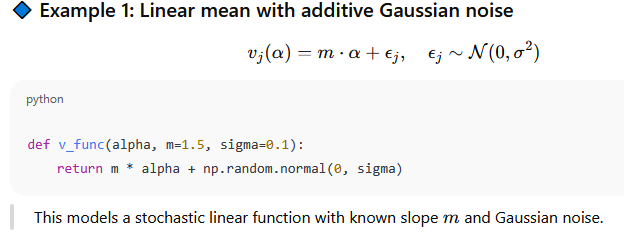

In [2]:
def v_func_Gaus(alpha, m=1.5, sigma=0.1):
    return m * alpha + np.random.normal(0, sigma)

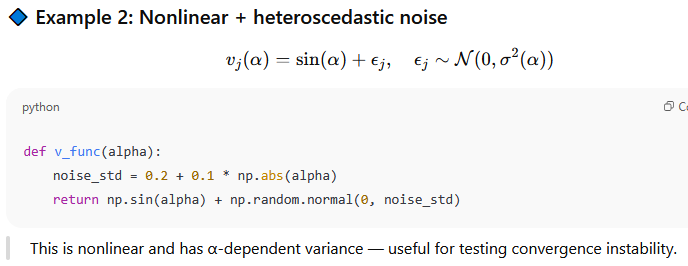

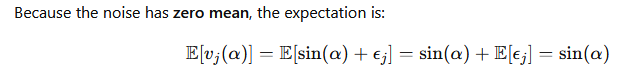

In [3]:
def v_func_NL(alpha):
    noise_std = 0.2 + 0.1 * np.abs(alpha)
    return np.sin(alpha) + np.random.normal(0, noise_std)

This function has no globally uniform expectation function, and may cause unpredictable convergence.

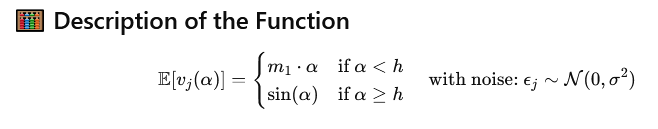

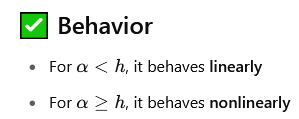

In [2]:
def sample_v_func_NU(alpha: float, n: int, m1: float = 1.0, h: float = 8.0, sigma: float = 0.1) -> torch.Tensor:
    """
    PyTorch-compatible stochastic function with piecewise expectation.
    This function has no globally uniform expectation function, and may cause unpredictable convergence.

    PyTorch-compatible stochastic function with piecewise expectation:
    E[v_j(α)] = -(α - 5)^2 + 6 for α < h
    E[v_j(α)] = m1*α - 11 for α ≥ h

    Parameters:
        alpha : float       # Current parameter value
        m1    : float       # Linear slope in region α > h
        h     : float       # Breakpoint separating regions
        sigma : float       # Standard deviation of Gaussian noise

    Returns:
        v_j : torch.Tensor  # One sample from v_j(α)
    """
    alpha_tensor = torch.tensor(alpha, dtype=torch.float32)    # ensure it's a float

    if alpha < h:
        mean = -((alpha_tensor - 5) ** 2) + 6
    else:
        mean = m1*alpha_tensor - 11
    
    noise = torch.normal(mean=0.0, std=sigma, size=(n,))
    samples = mean + noise  # broadcasting scalar mean over n noise samples
    return samples  # Return a tensor of a batch of n stochastic samples with torch.Size([1000]). Each sample is: vj​(α) = mean(α) + Gaussian noise

##### Define the Variables Initially

In [83]:
alpha = 1.0  # α: current parameter value (float)
v_d  = 7.0  # v_d: target value (float)
n_ini = 1000  # n_ini: initial number of samples per iteration (int)
lamb = 0.01  # λ: variance penalty weight (float)
gamma = 0.01  # γ: learning rate (float)
ep_tol = 1e-8  # ε: small constant for numerical stability and tolerance (float)
h = 0.1  # h: probing step size for finite difference (float)

In [4]:
n = 1000000
v1 = sample_v_func_NU(alpha=alpha, n=n)  # Sample from linear region

##### Systemic Function Calculation Class Notes

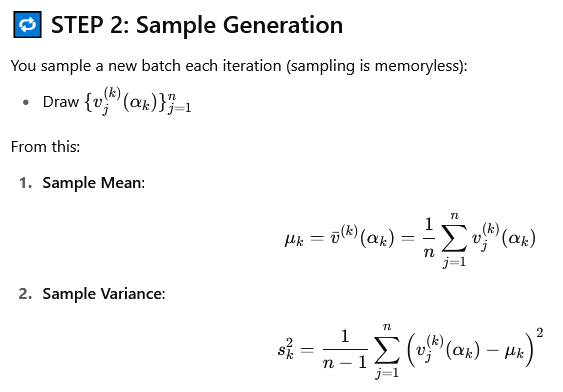

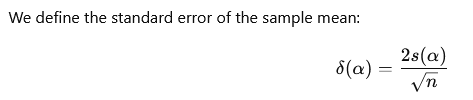

##### Systemic Function Class

In [ ]:
class MacroStats:
    def __init__(self, epsilon=1e-8, slope_tol=0.01, stderr_tol=2.0):
        # Store records as list of dicts with each α and its statistics
        self.records = []  # Each item: {"alpha": α, "mu": μ, "var": s², "stderr": δ}
        # Store Polyak–Ruppert slope history as torch tensor list
        self.slope_history = []  # list of torch scalars
        # Parameters for stability, tolerance, confidence
        self.epsilon = epsilon                    # numerical stability (denominator guard)
        self.slope_tol = slope_tol                # convergence threshold for m_k
        self.stderr_tol = stderr_tol              # multiplier for stderr-based agreement
        # Most recent slope estimate
        self.m_k = None  ## type: torch.Tensor or None

    def macro_observations(self, alpha: float, samples: torch.Tensor, decimals: int = 6):
        """
        Register a new observation (α, {v_j(α)}), and compute macroscopic statistics.
        Given:
            - α: The current parameter value
            - {v_j(α)}: A batch of n sampled stochastic values at α
        Computes:
            - Sample mean:
                μ(α) ≈ (1/n) ∑_{j=1}^n v_j(α)
            - Sample variance (unbiased estimator):
                s²(α) ≈ (1 / (n - 1)) ∑_{j=1}^n (v_j(α) - μ(α))²
            - Approximate standard error bound (95% confidence):
                This is a confidence bound, based on the approximation that ~95% of sample means (if resampled many times) fall within this range under the Central Limit Theorem as:
                μ ± 2⋅SE(α)
                δ(α) ≈ (2s(α)) / √n
        Stores:
            {"alpha": α, "mu": μ, "var": s², "stderr": δ} as a dict in self.records
        Returns:
            - μ(α), s²(α), δ(α)
        """
        # Round α to consistent float precision
        alpha_rounded = round(float(alpha), decimals)
        alpha_tensor = torch.tensor(alpha_rounded, dtype=torch.float32)
        mu = samples.mean() # Sample mean.
        var = samples.var(unbiased=True) # Sample variance.
        std = torch.sqrt(var) # Sample standard deviation.
        stderr_ci = 2 * std / torch.sqrt(torch.tensor(len(samples), dtype=torch.float32)) # Standard error bound (95% CI).

        
        # Create the record as a dict of torch scalars
        record = {
            "alpha": alpha_tensor,  # Alpha value.
            "n": len(samples),  # Number of samples.
            "mu": mu,  # Sample average.
            "var": var,  # Sample variance.
            "std": std,  # Sample standard deviation
            "stderr_ci": stderr_ci  # Sample standard error bound (95% CI).
        }

        # Check if alpha already exists. If so, replace it.
        for i, r in enumerate(self.records):
            if round(float(r["alpha"]), decimals) == alpha_rounded:
                self.records[i] = record
                break
        else:
            # Update the record within the function.
            self.records.append(record)

        return record  # Optionally return information for inspection.
    
    def suggest_step_size(self, alpha: float, vd: float, d: int = 1, kappa: float = 100.0, min_h: float = 1e-3) -> float:
        """
        Suggest a finite difference step size h for probing μ(α) with adaptive scaling based on fitness error |μ(α) - v_d|.

        The step size is computed as:
            h = max(sqrt(d + κ) ⋅ s(α) / √n, dynamic_min_h)
        where:
            - d is the dimensionality of the input (default 1).
            - κ is a spread control parameter.
            - σ_α is the estimated standard deviation of the input parameter α.
            - dynamic_min_h increases based on how far μ(α) is from v_d.
        
        Since σ_α is not directly known, it is approximated from the observed output variance
        as:
            σ_α ≈ s(α) / √n
        where s(α) is the sample standard deviation of {v_j(α)}, and n is the sample size.
        Now, the step size is computed as:
            h ≈ sqrt(d + κ) ⋅ s(α) / √n
        Parameters:
            - alpha (float): The parameter location α to retrieve step size for.
            - d (int): Dimension of α, (default 1).
            - kappa (float): Spread parameter controlling sigma point scaling.
            - min_h (float): Floor value to prevent degenerately small step size, (default 1e-3).
        Returns:
            - h (float): Recommended probing step size for finite difference or sigma point generation
        """
        # Specified alpha.
        alpha_tensor = alpha.clone().detach().to(dtype=torch.float32) if isinstance(alpha, torch.Tensor) else torch.tensor(alpha, dtype=torch.float32)
        # Search for matching α
        match = next((r for r in self.records if torch.isclose(r["alpha"], alpha_tensor, atol=1e-6)), None)
        if match is None:
            raise ValueError(f"No statistics found for α = {alpha} in recorded macroscopic observations.")


        # Dynamically increase floor for step size if far from target
        fitness_error = abs(mu.item() - v_d)

        if fitness_error > 1.0:
            dynamic_min_h = 0.5
        elif fitness_error > 0.1:
            dynamic_min_h = 0.05
        else:
            dynamic_min_h = min_h

        s = match["std"]  # Sample standard deviation of v_j(α).
        n = match["n"]  # Sample size at this α (Python int).
        mu = match["mu"]  # Sample average at this α.

        sigma_alpha = s / torch.sqrt(torch.tensor(n, dtype=torch.float32))
        h = torch.sqrt(torch.tensor(d + kappa, dtype=torch.float32)) * sigma_alpha
        h = torch.maximum(h, torch.tensor(dynamic_min_h))

        print(f"sigma_alpha = {sigma_alpha}, fitness_error = {fitness_error}, h = {h}, floor = {dynamic_min_h}")
        return h.item()

##### Plotting Macro Functions and Test Function

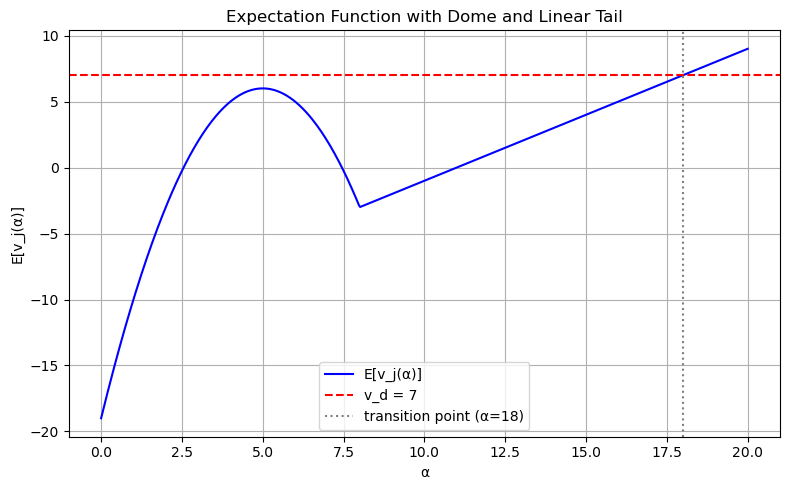

In [9]:
def expected_v_np(alpha):
    return np.where(
        alpha < 8,
        -(alpha - 5) ** 2 + 6,
        alpha - 11
    )

alpha_vals = np.linspace(0, 20, 600)
expectation_vals = expected_v_np(alpha_vals)

plt.figure(figsize=(8, 5))
plt.plot(alpha_vals, expectation_vals, label="E[v_j(α)]", color="blue")
plt.axhline(y=7, color="red", linestyle="--", label="v_d = 7")
intersect = 18
plt.axvline(x=intersect, color="gray", linestyle=":", label=f"transition point (α={intersect})")
plt.title("Expectation Function with Dome and Linear Tail")
plt.xlabel("α")
plt.ylabel("E[v_j(α)]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [121]:
# Instantiate the MacroStats class
stats = MacroStats()

In [122]:
# Define sampling parameters
alphas = list(range(0, 22, 1))  # α = 0, 1, ...
n = 1000000
# Collect macro observations for each α
for α in alphas:
    samples = sample_v_func_NU(alpha=α, n=n)
    stats.macro_observations(alpha=α, samples=samples)

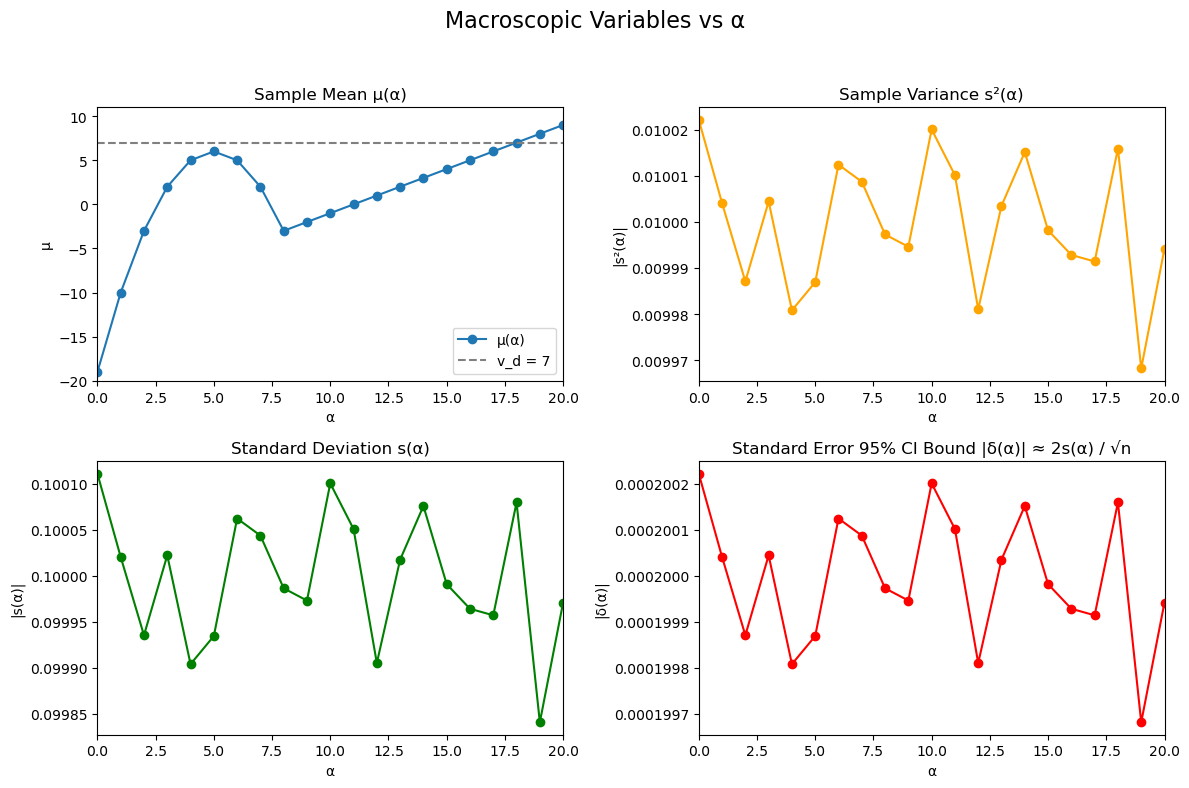

In [123]:
# Extract data from records
alphas = [r["alpha"].item() for r in stats.records]
mus    = [r["mu"].item()     for r in stats.records]
vars_  = [r["var"].item()    for r in stats.records]
stds   = [r["std"].item()    for r in stats.records]
stderrs= [r["stderr_ci"].item() for r in stats.records]

# Define v_d for reference
v_d = 7.0

# Create 2x2 plot
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Macroscopic Variables vs α", fontsize=16)

# Plot 1: μ(α)
axs[0, 0].plot(alphas, mus, marker='o', label='μ(α)')
axs[0, 0].axhline(v_d, color='gray', linestyle='--', label='v_d = 7')
axs[0, 0].set_title("Sample Mean μ(α)")
axs[0, 0].set_xlabel("α")
axs[0, 0].set_ylabel("μ")
axs[0, 0].legend()
axs[0, 0].set_xlim([0, 20])            # Domain
axs[0, 0].set_ylim([min(mus) - 1, max(mus) + 1])  # Range with padding

# Plot 2: s²(α)
axs[0, 1].plot(alphas, vars_, marker='o', color='orange')
axs[0, 1].set_title("Sample Variance s²(α)")
axs[0, 1].set_xlabel("α")
axs[0, 1].set_ylabel("|s²(α)|")
axs[0, 1].set_xlim([0, 20])
# axs[0, 1].set_ylim([min(vars_) - 0.01, max(vars_) + 0.01])

# Plot 3: s(α)
axs[1, 0].plot(alphas, stds, marker='o', color='green')
axs[1, 0].set_title("Standard Deviation s(α)")
axs[1, 0].set_xlabel("α")
axs[1, 0].set_ylabel("|s(α)|")
axs[1, 0].set_xlim([0, 20])
# axs[1, 0].set_ylim([min(stds) - 0.01, max(stds) + 0.01])

# Plot 4: δ(α)
axs[1, 1].plot(alphas, stderrs, marker='o', color='red')
axs[1, 1].set_title("Standard Error 95% CI Bound |δ(α)| ≈ 2s(α) / √n")
axs[1, 1].set_xlabel("α")
axs[1, 1].set_ylabel("|δ(α)|")
axs[1, 1].set_xlim([0, 20])
# axs[1, 1].set_ylim([min(stderrs) - 0.001, max(stderrs) + 0.001])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

##### Step Size Notes

Choose a finite-difference step size h for probing μ(α), large enough that the estimated change in μ is detectable above sample noise, but not so large that it moves into unrelated nonlinear regions.

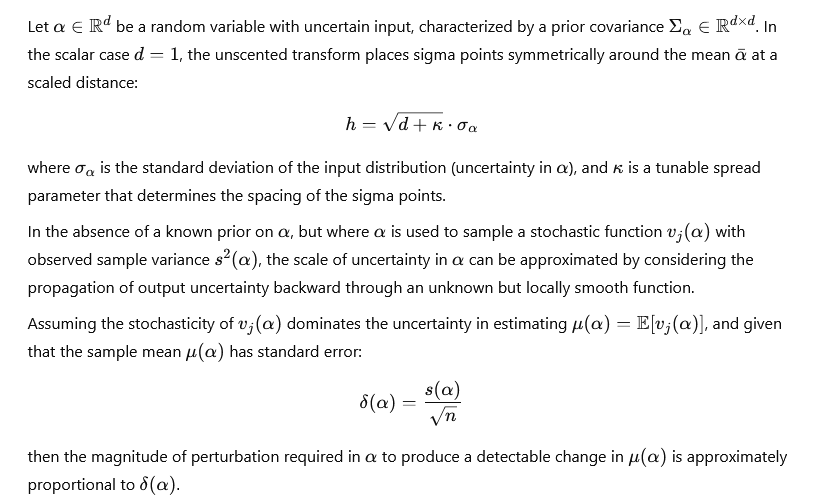

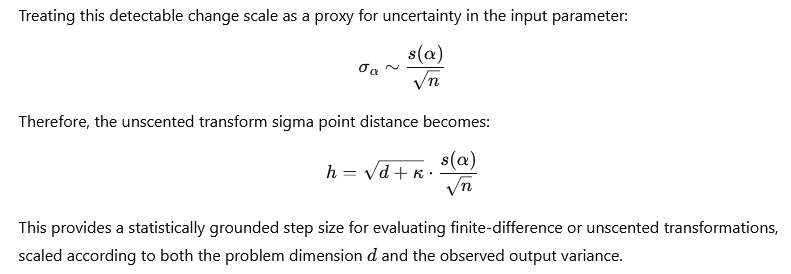

In [124]:
# def suggest_step_size(self, d: int = 1, kappa: float = 1.0, min_h: float = 1e-3) -> float:
#     """
#     Suggest a finite difference step size h for probing μ(α), based on an unscented transform principle.

#     The step size is computed as:
#         h = sqrt(d + κ) ⋅ σ_α
#     where:
#         - d is the dimensionality of the input (default 1),
#         - κ is a spread control parameter (commonly in [0, 3]),
#         - σ_α is the estimated standard deviation of the input parameter α.
#     Since σ_α is not directly known, it is approximated from the observed output variance
#     as:
#         σ_α ≈ s(α) / √n
#     where s(α) is the sample standard deviation of {v_j(α)}, and n is the sample size.
#     Now, the step size is computed as:
#         h ≈ sqrt(d + κ) ⋅ s(α) / √n
#     Parameters:
#         - d (int): Dimension of α, (default 1)
#         - kappa (float): Spread parameter controlling sigma point scaling, (default 1.0).
#         - min_h (float): Floor value to prevent degenerately small step size, (default 1e-3).
#     Returns:
#         - h (float): Recommended probing step size for finite difference or sigma point generation
#     """
#     if not self.records:
#         raise ValueError("No macroscopic records available to base step size on.")

#     latest = self.records[-1]
#     s = latest["std"]  # Sample standard deviation of v_j(α).
#     n = latest["n"]  # Sample size at this α (Python int).

#     sigma_alpha = s / torch.sqrt(torch.tensor(n, dtype=torch.float32))
#     h = torch.sqrt(torch.tensor(d + kappa, dtype=torch.float32)) * sigma_alpha
#     h = torch.maximum(h, torch.tensor(min_h))
#     return h.item()

# THIS FUNCTION HELPS DETERMINE THE NEXT STEP SIZE USING THE FUNCTION WITHIN THE CLASS macro_stats.
def probe_forward(macro_stats: MacroStats, alpha: float, v_func, n: int) -> float:
    """
    Given current α and a MacroStats object, compute a second α+h and record macro observations at α+h.

    Parameters:
        macro_stats (MacroStats): the statistics tracker
        alpha (float): current α
        v_func (callable): the sampling function to generate v_j(α)
        n (int): number of samples to draw at α+h

    Returns:
        record: the new macro observation dict at α+h
    """
    h = macro_stats.suggest_step_size(alpha)
    alpha_plus = alpha + h

    samples = v_func(alpha_plus, n)
    record = macro_stats.macro_observations(alpha_plus, samples)
    return record


##### Probe Forward Calculations

In [156]:
def get_alpha_pair(stats: MacroStats, alpha_k: float, atol: float = 0.01):
    """
    Retrieves the records for α_k and α_k+1 (i.e. α_k + h), assuming stats.records is sorted.

    Parameters:
        stats (MacroStats): The statistics object
        alpha_k (float): The α_k value
        atol (float): Tolerance for float comparison

    Returns:
        rec_k (dict): record at α_k
        rec_kp1 (dict): record at α_k + h
    """
    alpha_k_tensor = torch.tensor(alpha_k, dtype=torch.float32)

    # Find the index of the exact match
    index = next(
        (i for i, r in enumerate(stats.records) if torch.isclose(r["alpha"], alpha_k_tensor, atol=atol)),
        None
    )
    if index is None:
        raise ValueError(f"No record found for alpha_k = {alpha_k}")

    rec_k = stats.records[index]

    # Get the next record to the right in the sorted list
    if index + 1 >= len(stats.records):
        raise ValueError(f"No α_k+1 found after α_k = {alpha_k}")
    rec_kp1 = stats.records[index + 1]

    return rec_k, rec_kp1

In [126]:
alpha_start = 1.0
new_record = probe_forward(stats, alpha=alpha_start, v_func=sample_v_func_NU, n=100000)

sigma_alpha = 0.00010002038470702246, h = 0.0010051924036815763, min_h = 0.001


In [127]:
stats.records.sort(key=lambda r: float(r["alpha"]))

In [128]:
rec_k, rec_kp1 = get_alpha_pair(stats, alpha_k=3.0)
print(rec_k, rec_kp1)

{'alpha': tensor(3.), 'n': 1000000, 'mu': tensor(1.9999), 'var': tensor(0.0100), 'std': tensor(0.1000), 'stderr_ci': tensor(0.0002)} {'alpha': tensor(4.), 'n': 1000000, 'mu': tensor(4.9999), 'var': tensor(0.0100), 'std': tensor(0.0999), 'stderr_ci': tensor(0.0002)}


##### Finite Difference Calculations

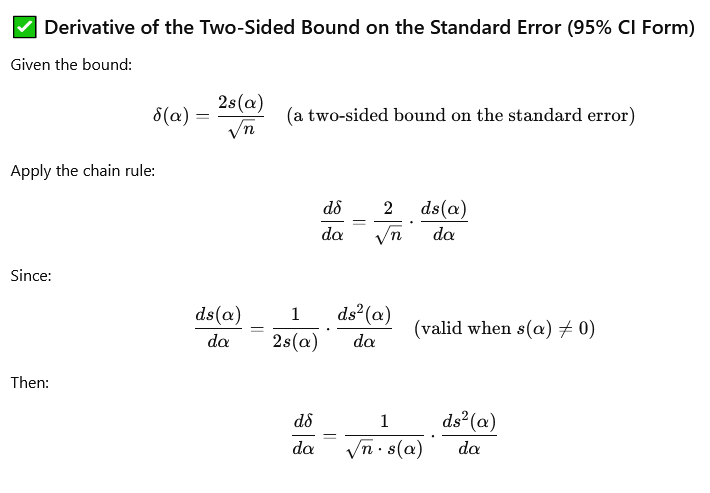

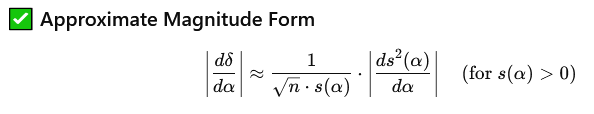

In [129]:
def finite_differences(rec_k: dict, rec_kp1: dict) -> dict:
    """
    Computes finite difference estimates between two macro records:
        - dμ/dα ≈ (μ_k+1 - μ_k) / (α_k+1 - α_k)
        - ds²/dα ≈ (s²_k+1 - s²_k) / (α_k+1 - α_k)

    Parameters:
        rec_k (dict): Record at α_k
        rec_kp1 (dict): Record at α_k + h

    Returns:
        dict with:
            - 'dmu_dalpha': float
            - 'dvar_dalpha': float
            - 'h': float (step size used)
    """
    α_k = rec_k["alpha"]
    α_kp1 = rec_kp1["alpha"]
    h = α_kp1 - α_k

    if torch.isclose(h, torch.tensor(0.0)):
        raise ValueError("Finite difference step h is zero.")

    dmu = (rec_kp1["mu"] - rec_k["mu"]) / h
    dvar = (rec_kp1["var"] - rec_k["var"]) / h

    return {
        "dmu_dalpha": dmu.item(),
        "dvar_dalpha": dvar.item(),
        "h": h.item()
    }

In [130]:
fd_results = finite_differences(rec_k, rec_kp1)
print(fd_results)

{'dmu_dalpha': 3.000013828277588, 'dvar_dalpha': -2.3623928427696228e-05, 'h': 1.0}


##### Loss Function and Derivative

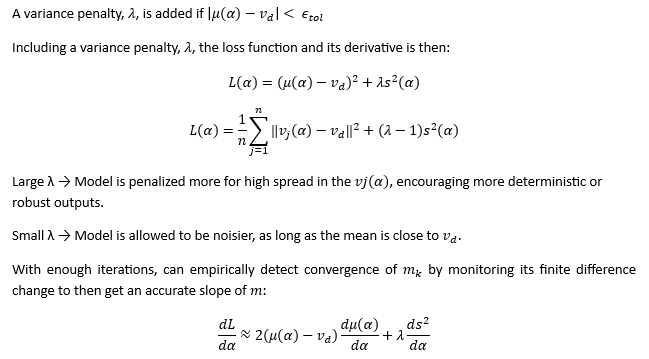

In [131]:
def decide_next_alpha(alpha_k: float,
                      rec_k: dict,
                      rec_kp1: dict,
                      fd_results: dict,
                      v_d: float,
                      lamb: float = 0.01,
                      gamma: float = 1.0,
                      slope_tol: float = 1e-3,
                      fitness_tol: float = 0.1,
                      clip_max_step: float = 1.0) -> float:
    """
    Decide the next alpha value based on loss gradient, fitness comparison, and slope behavior.

    Parameters:
        alpha_k (float): current α
        rec_k (dict): macro record at α_k
        rec_kp1 (dict): macro record at α_k + h
        fd_results (dict): finite difference results with dmu/dα, dvar/dα, h
        v_d (float): target value
        λ (float): variance penalty weight
        γ (float): learning rate multiplier
        slope_tol (float): threshold for detecting slope collapse
        fitness_tol (float): tolerance for saying we're "close" to target
        clip_max_step (float): maximum allowed update magnitude (safety, early in training, gradients can be very steep).

    Returns:
        alpha_next (float): suggested next α
    """
    mu_k = rec_k["mu"]
    mu_kp1 = rec_kp1["mu"]
    dmu_dalpha = fd_results["dmu_dalpha"]
    dvar_dalpha = fd_results["dvar_dalpha"]
    h = fd_results["h"]

    # Gradient estimate of the loss
    dL_dalpha = 2 * (mu_k - v_d) * dmu_dalpha + lamb * dvar_dalpha
    print(f"dL/dα = {dL_dalpha}")

    # Fitness improvement check
    fitness_k = abs(mu_k - v_d)
    fitness_kp1 = abs(mu_kp1 - v_d)

    # Slope collapse + far from target = likely trapped near peak
    if abs(dmu_dalpha) < slope_tol and fitness_k > fitness_tol:
        print("Override: slope too small, far from target → stepping forward")
        return alpha_k + h  # override with forward probe

    # Fitness override: go to α + h if it's closer to target
    if fitness_kp1 < fitness_k:
        print("Override: fitness improves at α + h → stepping forward")
        return alpha_k + h

    # Otherwise: follow gradient (with clipping)
    print("Follow α_k+1 = α_k + dL/dα")
    step = -gamma * dL_dalpha
    step = max(min(step, clip_max_step), -clip_max_step)
    return alpha_k + step

In [159]:
alpha_start = 4.5325026512146
samples = sample_v_func_NU(alpha=alpha_start, n=1000)
stats.macro_observations(alpha=alpha_start, samples=samples)
new_record = probe_forward(stats, alpha=alpha_start, v_func=sample_v_func_NU, n=100000)
rec_k, rec_kp1 = get_alpha_pair(stats, alpha_k=alpha_start)
fd_results = finite_differences(rec_k, rec_kp1)
print(fd_results)
print(decide_next_alpha(alpha_k = alpha_start,
                    rec_k = rec_k,
                    rec_kp1 = rec_kp1,
                    fd_results = fd_results,
                    v_d = v_d,
                    lamb = lamb,
                    gamma = gamma))

sigma_alpha = 0.003193859476596117, h = 0.032097890973091125, min_h = 0.001
{'dmu_dalpha': 1.3928486108779907, 'dvar_dalpha': -0.022551028057932854, 'h': 0.0020003318786621094}
dL/dα = -3.397169589996338
Override: fitness improves at α + h → stepping forward
4.534502983093262
